# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [53]:
# importar librerías
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [4]:
plans.head() # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
users.head() # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
usage.head() # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
users.info() # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:
# cantidad de nulos para users
print("Cantidad de valores nulos en users:")
print(users.isna().sum())# Cantidad de valores nulos)

print("\nProporción de valores nulos en users:")
print(users.isna().mean()) # Proporción de valores nulos)


Cantidad de valores nulos en users:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos en users:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [12]:
print("Cantidad de valores nulos en usage:")
print(usage.isna().sum())# cantidad de nulos para usage

print("\nProporción de valores nulos en usage:")
print(usage.isna().mean())

Cantidad de valores nulos en usage:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos en usage:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Respuesta**
**En users**
    - city
    Nulos: 469
    Proporción: 11.72% ausencia moderada
    Acción:si no es posible recuperar el dato, dejar como nulo

    - churn_date
    Nulos: 3.534
    Únicamente 466 usuarios cuentan con una fecha de cancelación registrada
    Proporción: 88.35% ausencia muy alta 
    Acción: no imputar ni eliminar la columna
    Pueden tener un significado para el negocio como: usuarios que no han cancelado el servicio y, por tanto no tienen una fecha de cancelación.
    Se conservarán como nulos y se utilizarán posteriormente para el análisis.

  El resto de columnas: user_id, first_name, last_name, age, reg_date y plan tienen 0 valores nulos o sin faltantes, con porporción del 0% y no requieren tratamiento. 

**En usage**
    - date
    Nulos: 20
    Porporción 0.12% muy pocos faltantes 
    Acción: investigar para imputar o dejarlos como nulos 

    - duration
    Nulos: 22.076 
    Proporción: 55.19% alta proporción de faltantes 
    Acción: no imputar, investigar el significado de los valores nulos 

    - legth
    Nulos: 17.896
    Proporción: 44.74% alta proporción de faltantes 
    Acción: no imputar, investigar el significado de los valores nulos 

 El resto de columnas: id, user_id y type tienen 0 valores nulos o sin faltantes, con porporción del 0% y no requieren tratamiento.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [13]:
users.describe().T # explorar columnas numéricas de users

,count,mean,std,min,25%,50%,75%,max
user_id,4000.0,11999.50000,1154.844867,10000.0,10999.75,11999.5,12999.25,13999.0
age,4000.0,33.73975,123.232257,-999.0,32.00,47.0,63.00,79.0


- La columna `user_id` 
  La columna user_id presenta 4.000 registros y no tiene valores nulos. Los identificadores van desde 10.000 hasta 13.999. La media y la mediana indican una distribución uniforme. 
- La columna `age`
  La columna age presenta 4.000 registros. Se observa una edad máxima de 79 años y valores habituales entre 32 y 63 años, correspondientes al primer y tercer cuartil. Sin embargo, el valor mínimo es -999, lo cual no corresponde a una edad válida y constituye un   sentinel o valor inválido. Este valor también afecta la media y la desviación estándar.

In [14]:
usage.describe().T # explorar columnas numéricas de usage

,count,mean,std,min,25%,50%,75%,max
id,40000.0,20000.500000,11547.149720,1.0,10000.7500,20000.5,30000.25,40000.0
user_id,40000.0,12002.405975,1157.279564,10000.0,10996.0000,12013.0,13005.00,13999.0
duration,17924.0,5.202237,6.842701,0.0,1.4375,3.5,6.99,120.0
length,22104.0,52.127398,56.611183,0.0,37.0000,50.0,64.00,1490.0


- Las columnas `id` contiene 40.000 registros entre 1 y 40.000. No se observan valores negativos, cero ni valores fuera del rango, por lo que no se identifican sentinels o valores inválidos.
- Las columnas `user_id` contiene 40.000 registros no presenta valores inválidos o sentinels evidentes. Es una variable identificadora y no una variable numérica.

In [15]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for columna in columnas_user:
    print(f"\nDistribución de {columna}:")
    print(users[columna].value_counts(dropna=False))



Distribución de city:
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Distribución de plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city`
  Las ciudades registradas son Bogotá, Ciudad de México, Medellín, Guadalajara, Cali y Monterrey (Países: Colombia y México) Los valores NaN y ?.
  Se identifican valores faltantes (NaN) en 469 registros (equivalentes al 11,73% del total).
  Se encuentra el valor ? en 96 registros (equivalente al 2,40%) se considera un posible sentinel o valor inválido, ya que no corresponde a ninguna ciudad.
- La columna `plan`
  se identifican dos categorías: Basico con 2.595 registros y Premium con 1.405 registros.
  No se observan valores nulos ni categorías inválidas o sentinels, por lo que esta columna no requiere tratamiento.

In [16]:
# explorar columna categórica de usage
usage['type']
print("Distribución de type:")
print(usage['type'].value_counts(dropna=False)) # completa el código

Distribución de type:
text    22092
call    17908
Name: type, dtype: int64


- La columna `type` contiene dos categorías:
  text con 22.092 registros (55,23%)
  call con 17.908 registros (44,77%)
  No se identifican valores nulos, sentinels ni categorías evidentemente inválidas. Por tanto, la variable presenta valores consistentes y no requiere tratamiento en esta etapa.
  usage: duration tiene sentido para los registros call, mientras que length tiene sentido para los registros text.
  Esto será especialmente útil para explicar por qué esas dos columnas tienen tantos valores nulos.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?, ¿Qué acción tomarías?
  
    Se identificó un valor potencialmente inválido o sentinel en la columna **city** del dataset users.
    Se recomienda reemplazarlo por NaN para tratarlo posteriormente como un dato faltante y evitar que afecte los análisis por ciudad.
  
    En la columna **age** del dataset users el valor mínimo es -999, lo cual no corresponde a una edad válida y constituye un sentinel o valor inválido. 
    Este valor también afecta la media y la desviación estándar, por lo que se recomienda reemplazar -999 por un valor nulo (NaN) antes de realizar el análisis por edad.
  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [17]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [18]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [19]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se observan registros correspondientes a los años 2022, 2023, 2024 y 2026. 
La mayor cantidad de registros se concentra entre 2022 y 2024. 
Sin embargo, aparecen 40 registros correspondientes a 2026, lo cual es inconsistente con el alcance del dataset, que contiene información registrada hasta 2024. 
Por lo tanto, estas fechas deben considerarse valores inválidos o errores y deben revisarse antes de realizar algún análisis.

In [20]:
usage['date'].dt.year.value_counts().sort_index() # Revisar los años presentes en `date` de usage

2024.0    39950
Name: date, dtype: int64

En `date`, de usage se observa que los 39.950 registros corresponden al año 2024. 
No se identifican registros de otros años. Por lo tanto, el análisis se basará en los datos correspondientes al año 2024. 

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
    En la columna **reg_date de users** se identificaron 40 registros correspondientes al año 2026.
    Estos valores están fuera del rango, ya que los datos del proyecto están registrados hasta el año 2024.Por lo tanto, se consideran fechas inválidas o posibles errores de captura.
    Como acción recomendada, se deben revisar para determinar si las fechas fueron registradas incorrectamente. Si no es posible corregirlas convertirlas en valores nulos (NaT) y excluirlas de los análisis que dependan de la fecha de registro o analizarlos para observar potenciales recomendaciones al momento del ingreso de la reg_date. 

  En la columna **date de usage**, los 39.950 registros corresponden al año 2024, por lo que no se identifican años fuera de rango.

  Se debe realizar un tratamiento específico sobre las fechas de **reg_date** correspondientes a **2026**, mientras que las fechas de usage pueden conservarse.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [21]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [22]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [23]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'] > pd.Timestamp('2024-12-31'), 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].describe()


count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [24]:
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean()) # Verificación MAR en usage (Missing At Random) para duration


type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [25]:
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())# Verificación MAR en usage (Missing At Random) para length


type
call    0.99933
text    0.00000
Name: length, dtype: float64

Diagnostico de nulos en `duration` y `length`
Los valores nulos de duration y length están relacionados directamente con la variable type.

En duration, el porcentaje de nulos es 0% para las llamadas y 99,93% para los mensajes. 
En length, el porcentaje de nulos es 99,93% para las llamadas y 0% para los mensajes.

Este patrón sigifica que es MAR dependiente de type. 
Según las evidencias evidencia se justifica dejarlos como nulos, porque la variable no aplica al otro tipo de interacción.

Llamadas corresponde al type-duration.

Mensajes corresponde al type-length.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.
  

In [26]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"}).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"}) 

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [29]:
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe().T # Resumen estadístico de las columnas numéricas


,count,mean,std,min,25%,50%,75%,max
age,4000.0,48.136000,17.689919,18.0,33.00,48.00,63.000,79.00
cant_mensajes,3999.0,5.524381,2.358416,0.0,4.00,5.00,7.000,17.00
cant_llamadas,3999.0,4.478120,2.144238,0.0,3.00,4.00,6.000,15.00
cant_minutos_llamada,3999.0,23.317054,18.168095,0.0,11.12,19.78,31.415,155.69


In [30]:
users['plan'].value_counts(normalize=True).sort_index() * 100 # Distribución porcentual del tipo de plan


Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

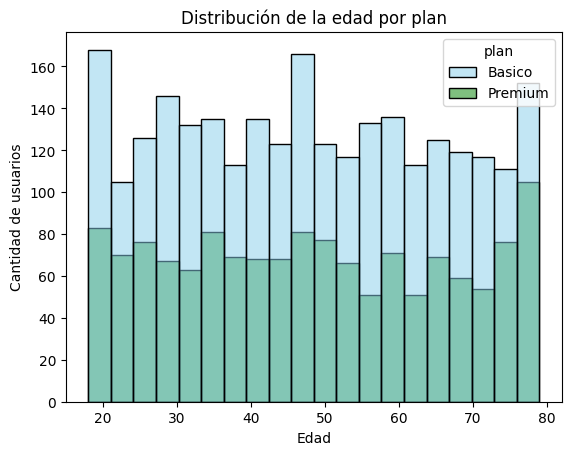

In [31]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], bins=20)

plt.title('Distribución de la edad por plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- **Distribución de la edad por plan**
  
  Se identifica que la variable de edad exhibe un comportamiento que se aproxima a una **distribución uniforme**, sin presentar un sesgo evidente hacia la derecha o hacia la izquierda.
  Esta tendencia general indica que **la base de usuarios abarca de manera constante todos los rangos desde los 18 hasta los 80 años**, presentando fluctuaciones menores pero manteniendo un volumen regular a lo largo del eje horizontal.
  Respecto al plan, no existe algún patrón que sugiera una preferencia demográfica marcada.
  **Tanto dentro del plan Premium como del plan Básico, la proporción de usuarios se mantiene estable en todas las edades.**
  Se observa que **el plan Básico suele concentrar una cantidad ligeramente mayor de usuarios en la mayoría de los segmentos comparado con el plan Premium**, pero la distancia proporcional entre ambos se conserva de forma paralela en la totalidad de la muestra.
  La información sugiere que **la edad de los usuarios no actúa como un factor diferenciador para predecir la inclinación hacia un tipo de plan específico**

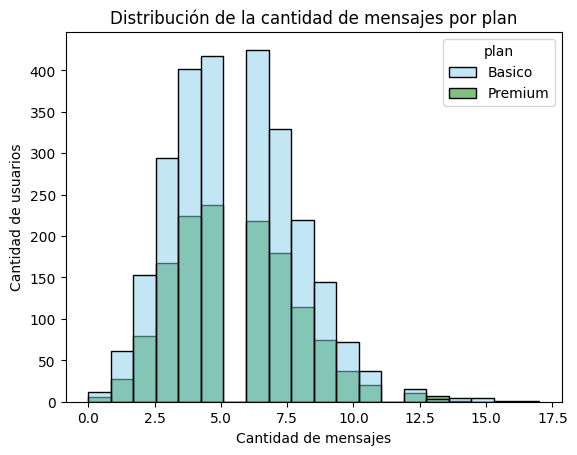

In [32]:
# Histograma para visualizar la cant_mensajes
sns.histplot( data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], bins=20)

plt.title('Distribución de la cantidad de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- **Distribución de la cantidad de mensajes por plan**

  Se evidencia que la variable presenta una **distribución sesgada a la derecha.** La mayor concentración de observaciones se agrupa en el intervalo de cuatro a ocho mensajes, **disminuyendo de forma progresiva y escalonada la cantidad de usuarios a medida que aumenta el volumen de mensajes enviados** hacia el extremo derecho del eje.
  
  En cuanto a la relación entre los servicios adquiridos y esta variable, no existe algún patrón que sugiera un comportamiento diferenciado entre los segmentos analizados. **Tanto dentro del plan Premium como del plan Básico, la proporción de usuarios conserva la misma forma de distribución y decae con idéntica tendencia hacia los valores superiores**. En consecuencia, **los usuarios de ambos planes tienden a enviar volúmenes similares de mensajes,** lo que permite determinar, que **el nivel de suscripción no constituye un factor condicionante en los hábitos de uso.**   

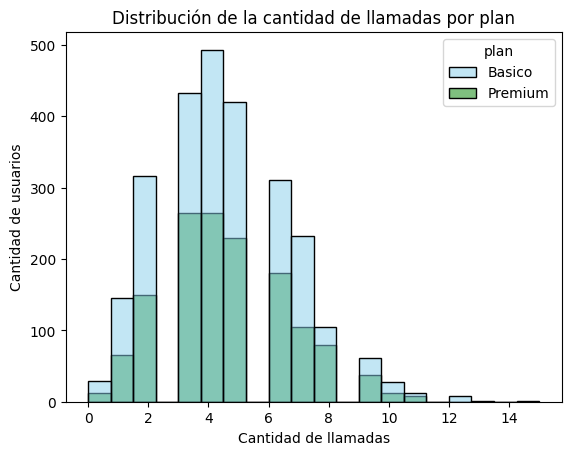

In [33]:
# Histograma para visualizar la cant_llamadas
sns.histplot( data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], bins=20)

plt.title('Distribución de la cantidad de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- **Distribución de la cantidad de llamadas por plan**
Se determina que la variable presenta una **distribución sesgada a la derecha.** La concentración principal de observaciones se sitúa en el intervalo de tres a cinco llamadas, tras lo cual la cantidad de usuarios decrece de manera paulatina al avanzar hacia el extremo superior del eje horizontal.

En relación con el plan: básico o premium, no existe algún patrón que evidencie variaciones significativas en el comportamiento operativo entre los diferentes segmentos. Tanto dentro del plan Premium como del plan Básico, la proporción de usuarios conserva la tendencia, lo que indica que **los clientes de ambos planes tienden a realizar volúmenes proporcionales de llamadas.** 

Se concluye, **la categoría de la suscripción adquirida no es un factor que modifique la frecuencia de llamadas efectuadas.**

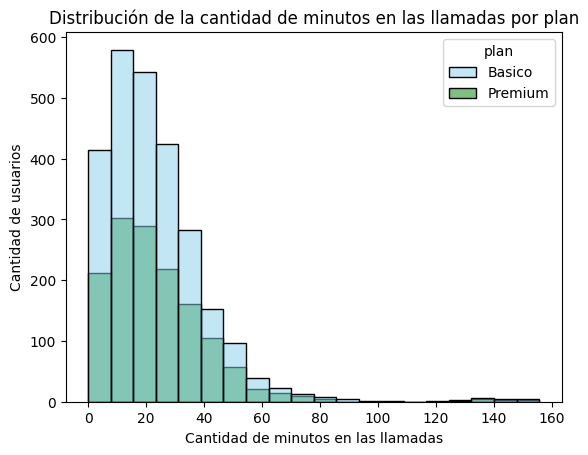

In [34]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], bins=20)

plt.title('Distribución de la cantidad de minutos en las llamadas por plan')
plt.xlabel('Cantidad de minutos en las llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- **Distribución de la cantidad de minutos en las llamadas por plan**
Se observa una **distribución sesgada a la derecha.** La concentración de los datos se agrupa predominantemente en los valores iniciales, ubicando a la gran mayoría de los usuarios en un rango de duración que oscila entre los cero y los treinta minutos, momento a partir del cual la frecuencia comienza a decaer drásticamente hasta conformar una cola extendida con observaciones aisladas que se aproximan a los 160 minutos.

Al evaluar la dinámica entre la cantidad de minutos consumidos y el tipo de servicio, **no existe algún patrón que sugiera un comportamiento atípico o diferenciado entre los segmentos de clientes. Tanto dentro del plan Premium como del plan Básico, la proporción de usuarios conserva la misma estructura decreciente,** manteniendo un volumen y una forma distributiva equivalentes a lo largo de todo el eje. 

Se concluye, que **la categoría del plan adquirido no es un factor determinante en la duración de las llamadas que realizan los usuarios.**

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

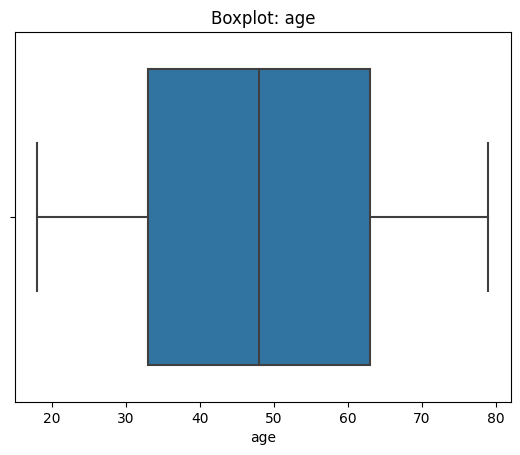

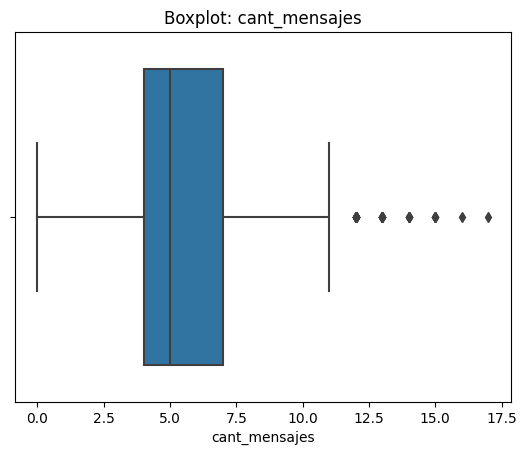

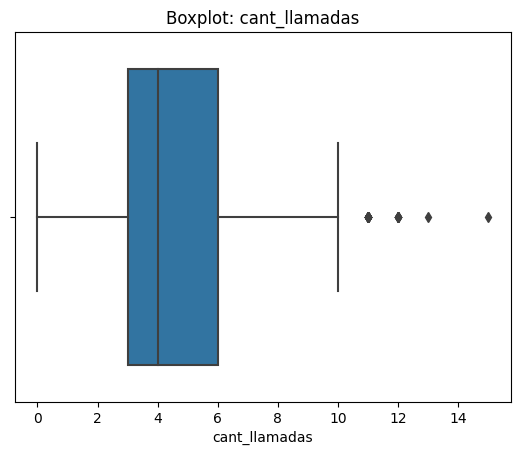

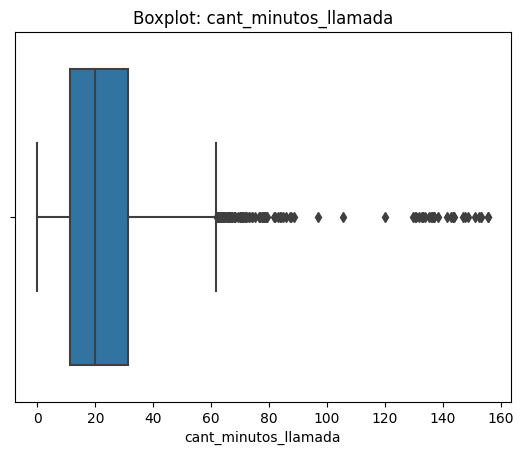

In [35]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡**Insights:** 
- **Age:**
Se determina que **no existen valores atípicos o outliers**. Los bigotes del gráfico se extienden hasta los valores mínimos y máximos de la muestra, los cuales **se ubican de forma aproximada entre los 18 y los 80 años, sin que se registren puntos de datos individuales que superen estos umbrales.**

- **cant_mensajes:**
Se identifica la **presencia de valores atípicos o outliers**. Estos valores anómalos se localizan de forma exclusiva **en el extremo derecho de la gráfica,** posicionándose por encima del bigote superior con observaciones puntuales que oscilan entre los 12 y los 17 mensajes aproximadamente. En contraste, la sección inferior de la distribución no exhibe datos atípicos.

Se procede determinar el límite superior mediante **(IQR).**

La acción recomendada es **aplicar la winsorización.**

- **cant_llamadas:**
Se constata la **existencia de valores atípicos o outliers**. Estos puntos de datos anómalos se sitúan exclusivamente en el segmento superior de la gráfica, proyectándose por encima del bigote derecho con **valores ubicados en 11, 12, 13 y 15 llamadas.**
Por el contrario, el extremo inferior de la distribución desciende hasta el valor de cero sin registrar observaciones atípicas.

Se procede a calcular el límite superior mediante **(IQR).** 

La acción recomendada es **aplicar la winsorización.**

- **cant_minutos_llamada:**
Se identifica una **alta densidad de valores atípicos o outliers.** Estos puntos anómalos se concentran exclusivamente en el segmento derecho del gráfico, extendiéndose de forma continua más allá del bigote superior desde aproximadamente los 60 minutos hasta valores cercanos a los 160 minutos.
Por el contrario, el límite inferior desciende hasta el valor de cero sin presentar observaciones atípicas.

Se procede a calcular el límite superior mediante **(IQR).** 

La acción recomendada es **aplicar la winsorización.**

In [39]:
# Calcular límites con el método IQR (1)
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for columna in columnas_limites:
    Q1 = user_profile[columna].quantile(0.25)
    Q3 = user_profile[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    outliers = user_profile[user_profile[columna] > limite_superior]

    print(f"{columna}: {len(outliers)} outliers")
    print(f"Límite superior: {limite_superior}")
    print()

cant_mensajes: 46 outliers
Límite superior: 11.5

cant_llamadas: 30 outliers
Límite superior: 10.5

cant_minutos_llamada: 109 outliers
Límite superior: 61.8575



In [41]:
# Calcular límites superiores con el método IQR (2)
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for columna in columnas_limites:
    Q1 = user_profile[columna].quantile(0.25)
    Q3 = user_profile[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    print(f"Variable: {columna}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Límite superior: {limite_superior}")
    print()

Variable: cant_mensajes
Q1: 4.0
Q3: 7.0
IQR: 3.0
Límite superior: 11.5

Variable: cant_llamadas
Q1: 3.0
Q3: 6.0
IQR: 3.0
Límite superior: 10.5

Variable: cant_minutos_llamada
Q1: 11.12
Q3: 31.415
IQR: 20.295
Límite superior: 61.8575



In [42]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡**Insights:** 
- **cant_mensajes:** 
Mantener aplicando la **Winsorización**, porque permite neutralizar la distorsión en los modelos analíticos posteriores sin incurrir en la pérdida de información relevante, debido a que los valores superiores en la cantidad de mensajes enviados representan un comportamiento real de los usuarios.

cant_mensajes: 46 outliers

Límite superior: 11.5
  
- **cant_llamadas:**
Mantener aplicando la **Winsorización**, porque se garantiza la mitigación del sesgo en el modelo sin incurrir en destrucción de datos reales y valiosos.
Estos niveles elevados en la cantidad de llamadas reflejan el comportamiento genuino de una fracción de usuarios con una alta demanda de comunicación, por lo que suprimir esta información alteraría la realidad.

cant_llamadas: 30 outliers

Límite superior: 10.5

- **cant_minutos_llamada:**
Mantener aplicando la **Winsorización**, porque esta alta concentración de datos en el extremo superior refleja el comportamiento real de un segmento de usuarios que hace un uso intensivo y prolongado del servicio de voz. Suprimir esta información alteraría la realidad operativa y generaría un sesgo en la comprensión.

cant_minutos_llamada: 109 outliers

Límite superior: 61.8575

**Análisis:**
Se identificaron valores atípicos en tres de las variables analizadas:

En cant_mensajes se encontraron 46 outliers por encima de 11,5 mensajes.

En cant_llamadas se identificaron 30 outliers por encima de 10,5 llamadas.

En cant_minutos_llamada se encontraron 109 outliers por encima de 61,8575 minutos.

Los outliers se encuentran únicamente en el extremo superior de las distribuciones. Estos valores no deben eliminarse automáticamente, ya que pueden representar usuarios con un nivel de consumo real significativamente superior al de la mayoría de los clientes. También podrían corresponder a errores de registro. 

Para este análisis, se conservarán los valores atípicos y se tendrán en cuenta al interpretar el comportamiento de los clientes, especialmente para identificar usuarios con patrones de consumo elevados y posibles oportunidades de segmentación comercial.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos.

In [61]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.select([
        (user_profile['cant_llamadas'] < 5) & 
        (user_profile['cant_mensajes'] < 5),

        (user_profile['cant_llamadas'] < 10) & 
        (user_profile['cant_mensajes'] < 10)],
    ['Bajo uso', 'Uso medio'], default='Alto uso')


In [62]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_edad,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Adulto,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Adulto,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Adulto,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Adulto Mayor,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Adulto Mayor,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [49]:
# Crear columna grupo_edad
user_profile['grupo_edad'] =np.select([user_profile['age'] < 30, user_profile['age'] < 60],['Joven','Adulto'], default='Adulto Mayor')

user_profile['grupo_edad'].value_counts()


Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

In [51]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

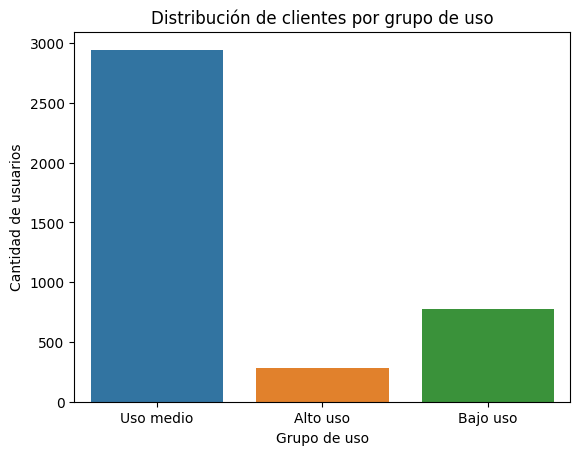

In [68]:
# Visualización de los segmentos por uso
sns.countplot( data=user_profile,x='grupo_uso')

plt.title('Distribución de clientes por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

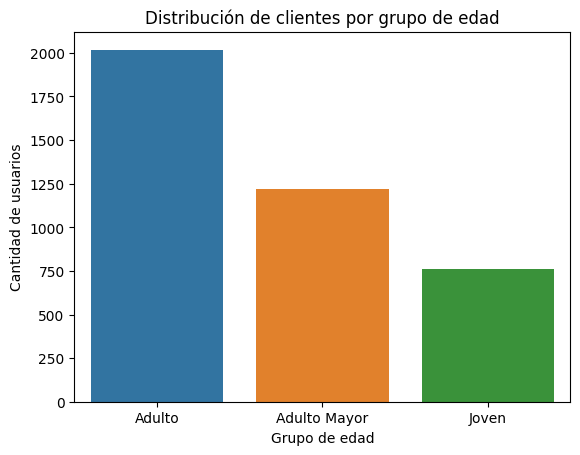

In [66]:
# Visualización de los segmentos por edad
sns.countplot( data=user_profile,x='grupo_edad')

plt.title('Distribución de clientes por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Se presentaron principalmente los siguientes problemas: 

- En la variable **city** se encontraron 469 valores nulos (11,73 %) y 96 registros con “?” (2,40 %). En conjunto, 565 usuarios (14,13 %) tenían información de ciudad ausente o inválida.
  
- En **age** se identificaron 55 registros con el valor imposible -999, equivalentes al 1,38 % de los usuarios. Estos valores distorsionaban las estadísticas de edad y fueron corregidos durante la limpieza.

- Se encontraron 40 **fechas de registro** en 2026 (1,0 %), aunque el periodo del análisis termina en 2024, por lo que se trataron como fechas inconsistentes.

- En **usage**, 50 registros (0,125 %) no tenían fecha.

- **duration** presentaba 22.076 valores nulos (55,19 %) y **length** 17.896 (44,74 %). El análisis mostró que estos nulos son principalmente estructurales, ya que duration corresponde a llamadas y length a mensajes, por lo cual no se imputaron.

- Los 3.534 valores nulos de **churn_date** (88,35 %) no se consideraron automáticamente errores, ya que pueden representar clientes que todavía no han abandonado el servicio.

- En **valores atípicos** se identificaron 46 usuarios con más de 11,5 mensajes, 30 con más de 10,5 llamadas y 109 con más de 61,86 minutos de llamada. Esto representa aproximadamente el 1,15 %, 0,75 % y 2,73 % de los usuarios con actividad, respectivamente.Estos valores no se eliminaron porque pueden representar clientes reales de alto consumo. Se recomienda revisarlos para diferenciar entre clientes intensivos, errores de registro y posibles anomalías.

🔍 **Segmentos por edad**
- Adultos: 2.018 usuarios (50,45 %).
- Adultos mayores: 1.222 usuarios (30,55 %).
- Jóvenes: 760 usuarios (19,00 %).

El **grupo predominante es el de adultos**, seguido por los **adultos mayores.** La edad promedio después de la limpieza es de aproximadamente **48 años.** Las distribuciones por plan no muestran una separación clara por edad, por lo que esta variable por sí sola no parece determinar la elección entre Básico y Premium.

📊 **Segmentos por nivel de Uso**
- El segmento predominante es **uso medio,** seguido por **bajo uso,** mientras que alto uso representa el grupo de menor tamaño.
  
- El **usuario típico** registra aproximadamente 5 mensajes, 4 llamadas y cerca de 20 minutos de llamada.

- Los **usuarios de alto uso** representan una oportunidad de crecimiento comercial, ya que pueden requerir mayores capacidades o beneficios. Sin embargo, con los datos disponibles no es posible afirmar que sean los clientes más rentables, porque no se cuenta con información de ingresos o margen por usuario.

- Se debe considerar que el **64,88 % de los clientes pertenece al plan básico y el 35,13 % a premium,** por lo que las diferencias visuales en los histogramas pueden estar influenciadas por el distinto tamaño de los grupos.

💡 **Recomendaciones**
**Decisiones comerciales**
1. **Crear ofertas diferenciadas según el nivel de consumo.** Diseñar alternativas para clientes de bajo, medio y alto uso, ajustando minutos, mensajes y beneficios a sus patrones reales de consumo.
2. **Ofrecer upgrades y beneficios adicionales a los clientes de alto uso.** Los usuarios con consumos elevados pueden requerir mayor capacidad y representan una oportunidad para ofrecer planes superiores o paquetes adicionales.
3. **Desarrollar estrategias de retención para el segmento de uso medio.** Este grupo concentra la mayor cantidad de usuarios, por lo que acciones de fidelización y personalización dirigidas a este segmento pueden tener un alcance importante.

**Decisiones ConnectaTel**

La principal oportunidad para ConnectaTel es pasar de una oferta general de planes a una **oferta segmentada** según el consumo real de sus clientes.

1. **Analizar conjuntamente edad, nivel de uso, plan y churn para personalizar las estrategias.** Cruzar estas variables permitiría identificar perfiles específicos de clientes y diseñar campañas de retención o migración más precisas.
2. **Mejorar la calidad de los datos e incorporar variables de rentabilidad y consumo de datos.** Corregir inconsistencias como fechas futuras, edades inválidas y datos faltantes, y complementar el análisis con GB consumidos, ingresos, cargos adicionales y rentabilidad. Esto permitiría tomar decisiones sobre los planes basándose no solo en el uso, sino también en el valor económico.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`